# Pooya Valizadeh
### CIFAR10 dataset
www.github.com/pooyavalizadeh


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

In [3]:
(xtrain, ytrain), (xtest, ytest) = keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [4]:
x = np.concatenate([xtrain, xtest], axis=0)
y = np.concatenate([ytrain, ytest], axis=0)

In [5]:
from sklearn.model_selection import train_test_split as tts

xtrain , xtest , ytrain , ytest = tts(x,y,random_state=26,stratify=y,test_size=0.15)

In [6]:
xtrain , xval ,ytrain, yval = tts(xtrain,ytrain,random_state=26,test_size=0.2)

In [7]:
xtrain.shape , ytrain.shape , xtest.shape , ytest.shape

((40800, 32, 32, 3), (40800, 1), (9000, 32, 32, 3), (9000, 1))

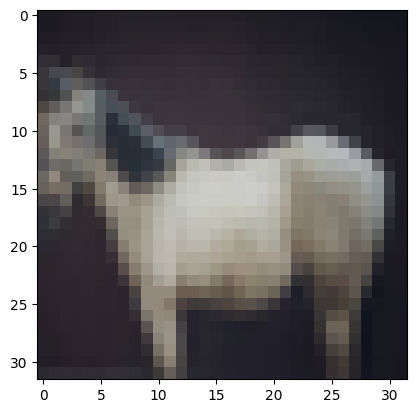

In [8]:
plt.imshow(xtrain[8585])

In [9]:
ytrain.shape

(40800, 1)

in this case , we should use 

sparse_categorical_crossentropy

but we can onehot the target and then use

categorical_crossentropy



**using to_categorical to onehot targets**

In [10]:
from keras.utils import to_categorical

ytrain = to_categorical(ytrain)
ytest = to_categorical(ytest)
yval = to_categorical(yval)

In [11]:
xtrain = xtrain / 255
xtest = xtest /255
xval = xval /255

# building first Model

In [17]:
model = keras.models.Sequential()
model.add(keras.layers.Input(shape = (32,32,3)))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(50,activation="relu",kernel_initializer = keras.initializers.HeNormal()))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dense(50,activation="relu",kernel_initializer=keras.initializers.HeNormal()))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dense(10,activation="softmax"))

In [18]:
model.compile(loss= "categorical_crossentropy",optimizer=keras.optimizers.Adam(),metrics=[
    keras.metrics.CategoricalAccuracy()
])

In [19]:
ytrain.shape

(40800, 10)

In [21]:
history = model.fit(xtrain,ytrain,validation_data=(xval,yval),epochs=100,batch_size = 100,callbacks=[
    keras.callbacks.EarlyStopping(patience=10,restore_best_weights=True)
])

Epoch 1/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - categorical_accuracy: 0.4663 - loss: 1.5229 - val_categorical_accuracy: 0.4099 - val_loss: 1.6439
Epoch 2/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - categorical_accuracy: 0.4746 - loss: 1.4944 - val_categorical_accuracy: 0.4393 - val_loss: 1.5776
Epoch 3/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - categorical_accuracy: 0.4836 - loss: 1.4680 - val_categorical_accuracy: 0.4274 - val_loss: 1.6287
Epoch 4/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - categorical_accuracy: 0.4875 - loss: 1.4487 - val_categorical_accuracy: 0.4362 - val_loss: 1.5941
Epoch 5/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - categorical_accuracy: 0.4963 - loss: 1.4257 - val_categorical_accuracy: 0.4192 - val_loss: 1.6438
Epoch 6/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - categorical_accuracy: 0.5022 - loss: 1.4112 - val_categorical_accuracy: 0.4371 - val_loss: 1.5930
Epoch 7/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - categorical_accuracy: 0

In [23]:
model.evaluate(xtest,ytest)

282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - categorical_accuracy: 0.4608 - loss: 1.5136


[1.5136033296585083, 0.46077778935432434]

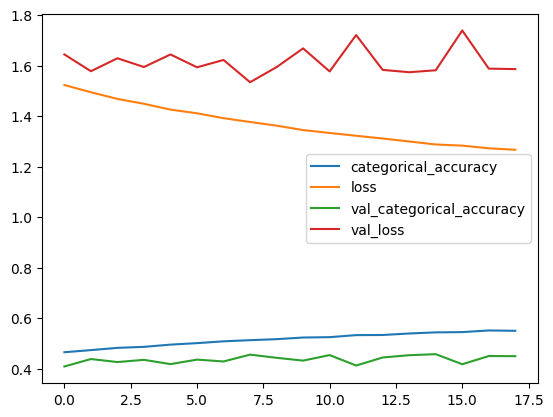

In [22]:
pd.DataFrame(history.history).plot()
plt.show()

In [24]:

def build_model(layers = 2 , units = 50 , lr = 0.01):
    model1 = keras.models.Sequential()
    model1.add(keras.layers.Input(shape = (32,32,3)))
    model1.add(keras.layers.Flatten())
    for i in range(units):
        model1.add(keras.layers.Dense(units,activation="relu"))
    model1.add(keras.layers.Dense(10,activation="softmax"))

    model1.compile(loss = keras.losses.CategoricalCrossentropy() , optimizer= keras.optimizers.SGD(learning_rate=lr))
    return model1

In [25]:
!pip install scikeras

In [26]:
from scikeras.wrappers import KerasClassifier
model_cl = KerasClassifier(build_model)

In [31]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.7 MB/s eta 0:00:00


In [32]:
import keras_tuner as kt

def build_hyper_model(hp):
    model = keras.models.Sequential()
    model.add(keras.layers.Input(shape=(32, 32, 3)))
    model.add(keras.layers.Flatten())

    for i in range(hp.Int('num_layers', min_value=2, max_value=6, step=1)):
        model.add(keras.layers.Dense(
            hp.Int(f'units_{i}', min_value=25, max_value=50, step=25),
            activation='relu',
            kernel_initializer=keras.initializers.HeNormal()
        ))
        model.add(keras.layers.BatchNormalization())

    model.add(keras.layers.Dense(10, activation='softmax'))
    hp_learning_rate = hp.Choice('learning_rate', values=[0.01, 0.001])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='categorical_crossentropy',
                  metrics=[keras.metrics.CategoricalAccuracy()])
    return model

In [33]:
tuner = kt.RandomSearch(
    build_hyper_model,
    objective='val_categorical_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='keras_tuner_dir',
    project_name='cifar10_hyperparam_tuning'
)

tuner.search(xtrain, ytrain, epochs=10, validation_data=(xval, yval),
             callbacks=[keras.callbacks.EarlyStopping(patience=5)])

Trial 10 Complete [00h 01m 32s]
val_categorical_accuracy: 0.43970587849617004

Best val_categorical_accuracy So Far: 0.47205883264541626
Total elapsed time: 00h 22m 20s


In [34]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"{best_hps.values}")

{'num_layers': 2, 'units_0': 50, 'units_1': 50, 'learning_rate': 0.001, 'units_2': 50, 'units_3': 25, 'units_4': 50}


In [35]:
best_model = tuner.get_best_models(num_models=1)[0]
best_model.evaluate(xtest, ytest)

/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - categorical_accuracy: 0.4717 - loss: 1.4904


[1.4903650283813477, 0.4716666638851166]

In [51]:
from sklearn.metrics import roc_curve, auc ,f1_score , accuracy_score
import numpy as np

y_pred_proba_test = best_model.predict(xtest)
fpr, tpr, thresholds = roc_curve(ytest[:, 2], y_pred_proba_test[:, 2], pos_label=1)
f_test = f1_score(np.argmax(ytest, axis=1), np.argmax(y_pred_proba_test, axis=1), average='weighted')
a_test = accuracy_score(np.argmax(ytest, axis=1), np.argmax(y_pred_proba_test, axis=1))


y_pred_proba_train = best_model.predict(xtrain)
fpr1, tpr1, thresholds1 = roc_curve(ytrain[:, 2], y_pred_proba_train[:, 2], pos_label=1)
f_train = f1_score(np.argmax(ytrain, axis=1), np.argmax(y_pred_proba_train, axis=1), average='weighted')
a_train = accuracy_score(np.argmax(ytrain, axis=1), np.argmax(y_pred_proba_train, axis=1))


y_pred_proba_val = best_model.predict(xval)
fpr2, tpr2, thresholds2 = roc_curve(yval[:, 2], y_pred_proba_val[:, 2], pos_label=1)
f_val = f1_score(np.argmax(yval, axis=1), np.argmax(y_pred_proba_val, axis=1), average='weighted')
a_val = accuracy_score(np.argmax(yval, axis=1), np.argmax(y_pred_proba_val, axis=1))


282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
1275/1275 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


# Metric of Train , Validation , Test

In [52]:

roc_auc_test = auc(fpr, tpr)
roc_auc_train = auc(fpr1, tpr1)
roc_auc_val = auc(fpr2, tpr2)
metrics_data = {
    'Metric': ['F1-score', 'Accuracy', 'ROC AUC'],
    'Train': [f_train, a_train, roc_auc_train],
    'Validation': [f_val, a_val, roc_auc_val],
    'Test': [f_test, a_test, roc_auc_test]
}
metrics_df = pd.DataFrame(metrics_data)
display(metrics_df)

,Metric,Train,Validation,Test
0,F1-score,0.506030,0.465435,0.465498
1,Accuracy,0.512647,0.472059,0.471667
2,ROC AUC,0.825084,0.797965,0.798943


In [53]:
input_ = keras.layers.Input(shape = (32,32,3))
flat = keras.layers.Flatten()(input_)
l1 = keras.layers.Dense(50 , activation="relu",kernel_initializer=keras.initializers.HeNormal())(flat)
l1_5 = keras.layers.BatchNormalization()(l1)
l4 = keras.layers.Dense(50 , activation="relu",kernel_initializer=keras.initializers.HeNormal())(l1_5)
l5 = keras.layers.concatenate(([flat,l4]))
l6 = keras.layers.Dense(10 , activation="softmax")(l5)
model = keras.Model(input_,l6)

In [54]:
model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 3072)      │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 50)        │    153,650 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50)        │        200 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 50)        │      2,550 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 3122)      │          0 │ flatten_1[0][0],  │
│ (Concatenate)       │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 10)        │     31,230 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 187,630 (732.93 KB)

 Trainable params: 187,530 (732.54 KB)

 Non-trainable params: 100 (400.00 B)

In [57]:
model.compile(loss = keras.losses.CategoricalCrossentropy() , optimizer="SGD",metrics=[keras.metrics.CategoricalAccuracy()])

In [58]:
history1 = model.fit(xtrain,ytrain,epochs=100,batch_size=100,validation_data=(xval,yval),
callbacks=keras.callbacks.EarlyStopping(patience=10,restore_best_weights=True))

Epoch 1/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - categorical_accuracy: 0.4155 - loss: 1.6615 - val_categorical_accuracy: 0.4001 - val_loss: 1.6818
Epoch 2/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - categorical_accuracy: 0.4290 - loss: 1.6183 - val_categorical_accuracy: 0.4145 - val_loss: 1.6439
Epoch 3/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - categorical_accuracy: 0.4416 - loss: 1.5895 - val_categorical_accuracy: 0.4115 - val_loss: 1.6696
Epoch 4/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - categorical_accuracy: 0.4531 - loss: 1.5628 - val_categorical_accuracy: 0.4223 - val_loss: 1.6119
Epoch 5/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - categorical_accuracy: 0.4597 - loss: 1.5398 - val_categorical_accuracy: 0.4231 - val_loss: 1.6321
Epoch 6/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - categorical_accuracy: 0.4664 - loss: 1.5186 - val_categorical_accuracy: 0.4331 - val_loss: 1.5819
Epoch 7/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - categorical_accuracy

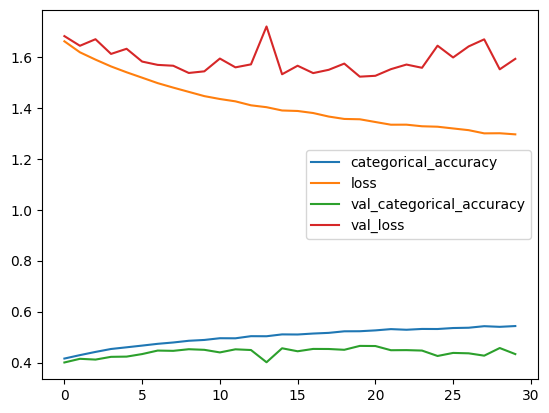

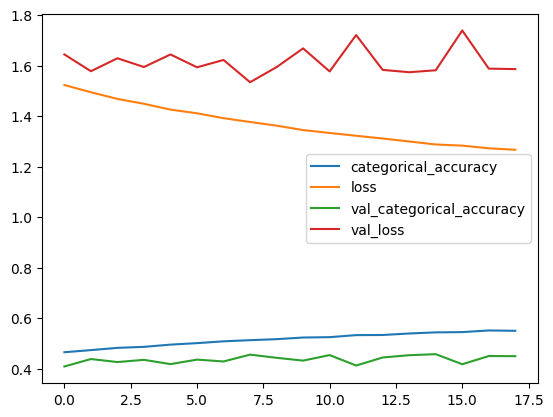

In [59]:
pd.DataFrame(history1.history).plot()
pd.DataFrame(history.history).plot()
plt.show()

In [60]:
model.evaluate(xtest,ytest)

282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - categorical_accuracy: 0.4763 - loss: 1.4990


[1.4990322589874268, 0.4763333201408386]

In [61]:
y_pred_proba_test = model.predict(xtest)
fpr, tpr, thresholds = roc_curve(ytest[:, 2], y_pred_proba_test[:, 2], pos_label=1)
f_test = f1_score(np.argmax(ytest, axis=1), np.argmax(y_pred_proba_test, axis=1), average='weighted')
a_test = accuracy_score(np.argmax(ytest, axis=1), np.argmax(y_pred_proba_test, axis=1))


y_pred_proba_train = model.predict(xtrain)
fpr1, tpr1, thresholds1 = roc_curve(ytrain[:, 2], y_pred_proba_train[:, 2], pos_label=1)
f_train = f1_score(np.argmax(ytrain, axis=1), np.argmax(y_pred_proba_train, axis=1), average='weighted')
a_train = accuracy_score(np.argmax(ytrain, axis=1), np.argmax(y_pred_proba_train, axis=1))


y_pred_proba_val = model.predict(xval)
fpr2, tpr2, thresholds2 = roc_curve(yval[:, 2], y_pred_proba_val[:, 2], pos_label=1)
f_val = f1_score(np.argmax(yval, axis=1), np.argmax(y_pred_proba_val, axis=1), average='weighted')
a_val = accuracy_score(np.argmax(yval, axis=1), np.argmax(y_pred_proba_val, axis=1))

282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
1275/1275 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [62]:
roc_auc_test = auc(fpr, tpr)
roc_auc_train = auc(fpr1, tpr1)
roc_auc_val = auc(fpr2, tpr2)
metrics_data = {
    'Metric': ['F1-score', 'Accuracy', 'ROC AUC'],
    'Train': [f_train, a_train, roc_auc_train],
    'Validation': [f_val, a_val, roc_auc_val],
    'Test': [f_test, a_test, roc_auc_test]
}
metrics_df = pd.DataFrame(metrics_data)
display(metrics_df)

,Metric,Train,Validation,Test
0,F1-score,0.527288,0.462711,0.474421
1,Accuracy,0.529559,0.465196,0.476333
2,ROC AUC,0.843890,0.803540,0.808052


***so in this dataset wide and deep model did better that normal deep model***